In [1]:
import pandas as pd
from pathlib import Path
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path.cwd().parents[0]

f = lambda file_name: BASE_DIR / "data" / "processed" / file_name

df_account = pd.read_csv(f("account.csv"))
df_demographic = pd.read_csv(f("demographic.csv"))
df_location = pd.read_csv(f("location.csv"))

In [2]:
print(df_account.columns)
print(df_demographic.columns)
print(df_location.columns)

Index(['CustomerId', 'Tenure', 'Balance', 'NumProducts', 'HasCreditCard',
       'IsActive'],
      dtype='str')
Index(['CustomerId', 'Gender', 'Age', 'Salary', 'LocationId', 'Churned'], dtype='str')
Index(['LocationId', 'Geography'], dtype='str')


In [3]:
set(df_account['CustomerId']) == set(df_demographic['CustomerId'])
df_merged = pd.merge(
    df_demographic, df_account,  how='inner', on='CustomerId'
)

Q1: Which customer profiles have the highest churn risk based on gender

In [4]:
gender_churned_rate = df_merged.groupby('Gender')['Churned'].agg(
    ['sum', 'count', 'mean']
).reset_index()

gender_churned_rate['mean'] = gender_churned_rate['mean'].round(2)

gender_churned_rate = gender_churned_rate.rename(columns={
    'sum': 'Total_Churned',
    'count': 'Total_Customers',
    'mean': 'Churn_Rate'
})
gender_churned_rate

,Gender,Total_Churned,Total_Customers,Churn_Rate
0,Female,1139,4543,0.25
1,Male,898,5457,0.16


---

-- Q2: How does churn rate vary across customer segments

In [5]:
df_merged_country = pd.merge(df_merged, df_location, how='left', on='LocationId')

In [6]:

bin_edges = [0, 29, 50, 100]
bin_labels = ['Under 30', '30-50', 'above 50']
df_merged_country['Age_Group'] = pd.cut(df_merged_country['Age'], bins=bin_edges, labels=bin_labels)

country_churned_rate = df_merged_country.groupby(['Geography', 'Age_Group'])['Churned'].agg(
    ['count', 'mean']
)
country_churned_rate['mean'] = country_churned_rate['mean']
country_churned_rate = country_churned_rate.rename(columns={
    'count' : 'Total',
    'mean' : 'AvgChurnRate'
}).reset_index()
# country_churned_rate


country_churned_rate['AvgChurnCountry'] = country_churned_rate.groupby('Geography')['AvgChurnRate'].transform('mean')
country_churned_rate['Diff'] = country_churned_rate['AvgChurnCountry'] - country_churned_rate['AvgChurnRate']

country_churned_rate
# country_churned_rate
# country_churned_rate.groupby('Geography')['AVG_Churn_Rate'].mean()

# country_churned_rate['CountaryAVG'] = country_churned_rate['Geography']['mean'].mean()

,Geography,Age_Group,Total,AvgChurnRate,AvgChurnCountry,Diff
0,Canada,Under 30,271,0.073801,0.227357,0.153557
1,Canada,30-50,1191,0.188917,0.227357,0.038441
2,Canada,above 50,217,0.419355,0.227357,-0.191997
3,France,Under 30,253,0.063241,0.232178,0.168937
4,France,30-50,1234,0.183955,0.232178,0.048224
5,France,above 50,227,0.449339,0.232178,-0.217161
6,Germany,Under 30,281,0.056940,0.218796,0.161857
7,Germany,30-50,1156,0.192042,0.218796,0.026755
8,Germany,above 50,189,0.407407,0.218796,-0.188611
9,Spain,Under 30,265,0.083019,0.237305,0.154286


In [7]:
country_churned_rate

,Geography,Age_Group,Total,AvgChurnRate,AvgChurnCountry,Diff
0,Canada,Under 30,271,0.073801,0.227357,0.153557
1,Canada,30-50,1191,0.188917,0.227357,0.038441
2,Canada,above 50,217,0.419355,0.227357,-0.191997
3,France,Under 30,253,0.063241,0.232178,0.168937
4,France,30-50,1234,0.183955,0.232178,0.048224
5,France,above 50,227,0.449339,0.232178,-0.217161
6,Germany,Under 30,281,0.056940,0.218796,0.161857
7,Germany,30-50,1156,0.192042,0.218796,0.026755
8,Germany,above 50,189,0.407407,0.218796,-0.188611
9,Spain,Under 30,265,0.083019,0.237305,0.154286


In [8]:
df_merged.columns

Index(['CustomerId', 'Gender', 'Age', 'Salary', 'LocationId', 'Churned',
       'Tenure', 'Balance', 'NumProducts', 'HasCreditCard', 'IsActive'],
      dtype='str')

-- How does churn behavior change when we dynamically sclice customers by buisness paramaters

In [9]:
MinTenure = 6
MaxBalance = 70000
MaxProduct = 7

df_filterd = df_merged[ (df_merged['Tenure'] > MinTenure) & (df_merged['Balance'] < MaxBalance) & (df_merged['NumProducts'] < MaxProduct) ]

In [10]:
df_filterd

,CustomerId,Gender,Age,Salary,LocationId,Churned,Tenure,Balance,NumProducts,HasCreditCard,IsActive
169,15611325,Male,24,53134.30,4,0,9,57929.81,2,0,0
190,15726931,Female,41,92982.61,1,1,8,56214.85,2,0,0
194,15679200,Male,29,128077.80,6,0,9,61710.44,2,1,0
216,15680920,Male,46,133007.34,3,0,7,49512.55,1,1,0
269,15799217,Female,35,161051.75,4,0,7,52436.20,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9616,15664539,Male,35,82951.12,3,0,9,61172.04,1,0,0
9646,15603111,Male,71,97893.40,4,1,10,69608.14,1,1,0
9713,15623566,Male,40,96687.25,5,0,9,46520.69,1,1,1
9787,15752626,Male,32,109159.58,4,0,7,64082.09,1,0,1


In [ ]:
# Show all columns without truncation
pd.set_option('display.max_columns', None)

print("Demographic Stats:")
display(df_demographic.describe(include='all'))

print("\nAccount Stats:")
display(df_account.describe())

Demographic Stats:


,CustomerId,Gender,Age,Salary,LocationId,Churned
count,1.000000e+04,10000,10000.000000,10000.000000,10000.000000,10000.000000
unique,NaN,2,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN
freq,NaN,5457,NaN,NaN,NaN,NaN
mean,1.569094e+07,NaN,38.921800,100090.239881,3.510200,0.203700
std,7.193619e+04,NaN,10.487806,57510.492818,1.704637,0.402769
min,1.556570e+07,NaN,18.000000,11.580000,1.000000,0.000000
25%,1.562853e+07,NaN,32.000000,51002.110000,2.000000,0.000000
50%,1.569074e+07,NaN,37.000000,100193.915000,4.000000,0.000000
75%,1.575323e+07,NaN,44.000000,149388.247500,5.000000,0.000000



Account Stats:


,CustomerId,Tenure,Balance,NumProducts,HasCreditCard,IsActive
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,1.569094e+07,5.012800,119827.493793,1.530200,0.70550,0.515100
std,7.193619e+04,2.892174,24043.366590,0.581654,0.45584,0.499797
min,1.556570e+07,0.000000,3768.690000,1.000000,0.00000,0.000000
25%,1.562853e+07,3.000000,111581.127500,1.000000,0.00000,0.000000
50%,1.569074e+07,5.000000,119827.493793,1.000000,1.00000,1.000000
75%,1.575323e+07,7.000000,127644.240000,2.000000,1.00000,1.000000
max,1.581569e+07,10.000000,250898.090000,4.000000,1.00000,1.000000


Age vs. Churn.

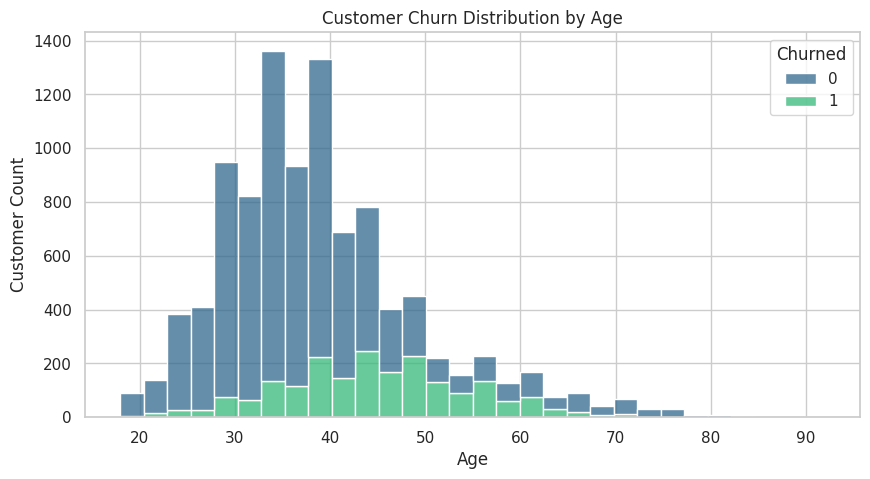

In [14]:
# Set visual style
sns.set_theme(style="whitegrid")

# Merge demographic and account data for plotting if not already merged
df_full = pd.merge(df_demographic, df_account, on="CustomerId")

plt.figure(figsize=(10, 5))
sns.histplot(data=df_full, x="Age", hue="Churned", multiple="stack", palette="viridis", bins=30)
plt.title("Customer Churn Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Customer Count")
plt.show()